In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from generator import Generator
from detector.canny_detect import CannyDetect
from PIL import Image
import json

In [3]:
base_model = 'black-forest-labs/FLUX.1-dev'
controlnet_model_union = '/amax/hchuz/hfd_models/FLUX.1-dev-ControlNet-Union-Pro'
flux_redux = 'black-forest-labs/FLUX.1-Redux-dev'
#flux_fill = '/amax/hchuz/hfd_models/FLUX.1-Fill-dev'
flux_fill = None
dino_checkpoint = '/amax/hchuz/OMG-master/checkpoint/GroundingDINO'
sam_checkpoint = '/amax/hchuz/OMG-master/checkpoint/sam/sam_vit_h_4b8939.pth'
lora_weights = '/amax/hchuz/ai-toolkit/output/my_first_flux_lora_v1/my_first_flux_lora_v1.safetensors'
offload = False

In [4]:
generator = Generator(base_model, controlnet_model_union, flux_redux, dino_checkpoint, sam_checkpoint, offload, flux_fill=flux_fill, lora_weights=lora_weights)
cannydetect = CannyDetect()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

final text_encoder_type: bert-base-uncased


Model loaded from groundingdino_swinb_cogcoor.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


In [5]:
data_dir = '相似的几个2'
names = [name[:-len('.png')] for name in os.listdir(data_dir) if name.endswith('.png')]
name = names[1]
with open(os.path.join(data_dir, name+'.json'), 'r') as f:
    data = json.load(f)
control_image = cannydetect.polygon2canny([sample['points'] for sample in data['shapes']])
global_style_image = Image.open(os.path.join(data_dir, name+'.png')).convert('RGB')

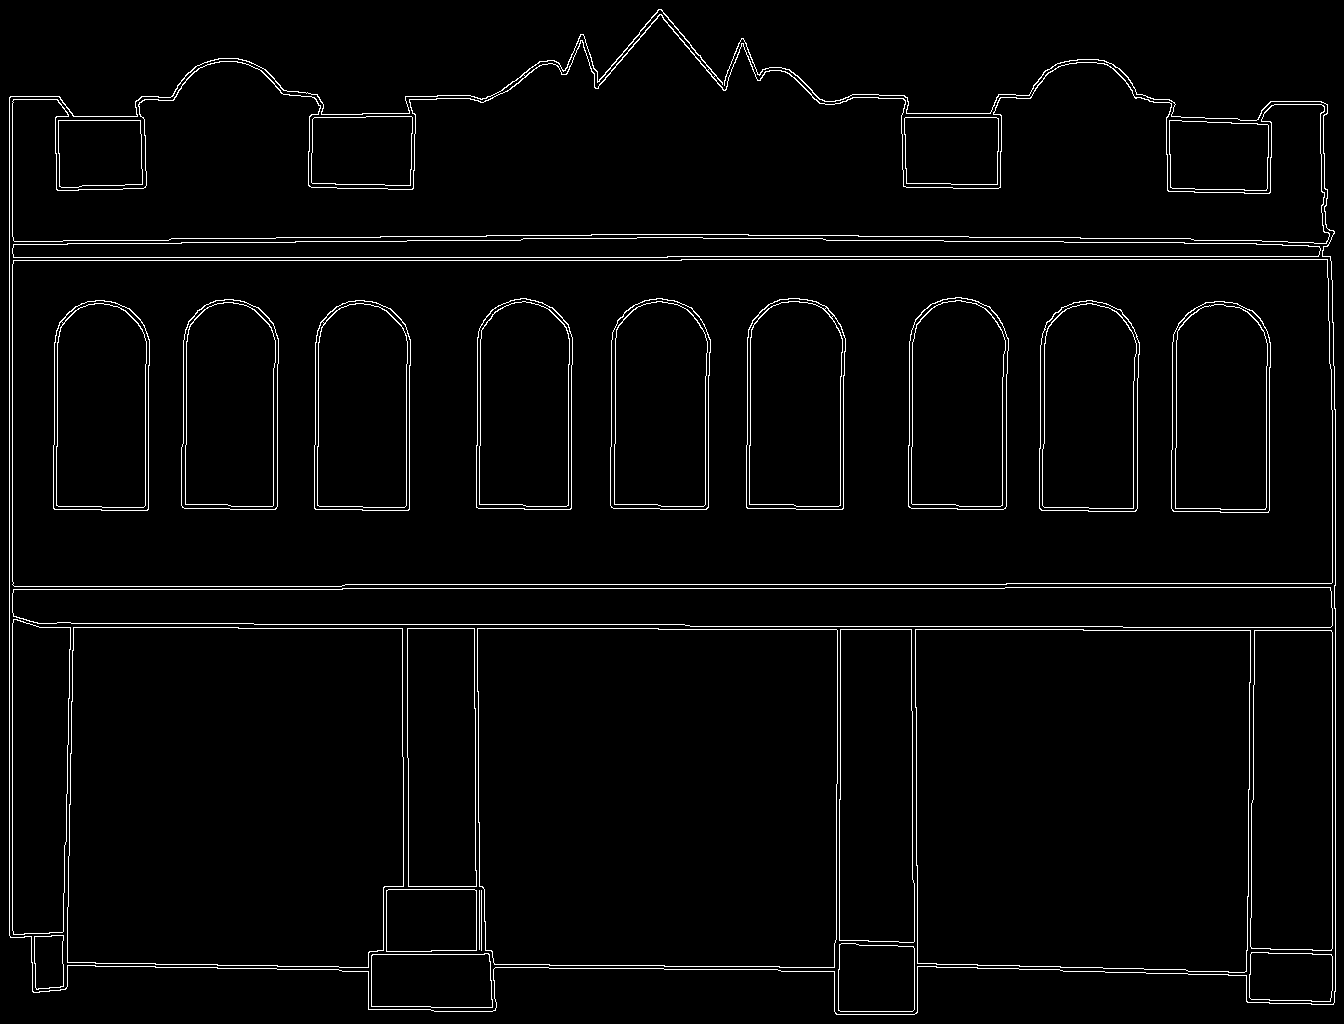

In [6]:
control_image

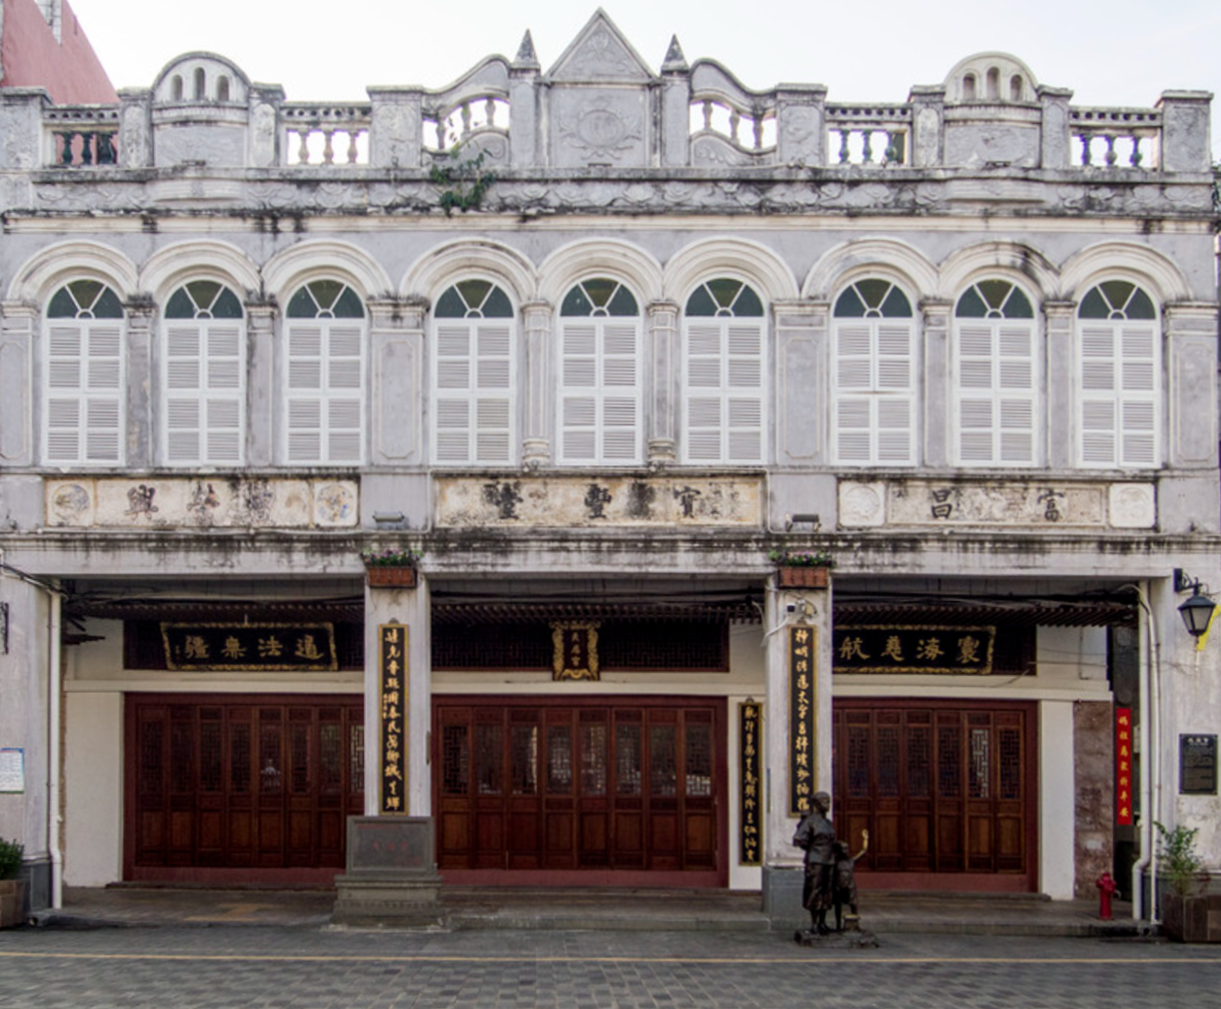

In [7]:
global_style_image

In [ ]:
#generator.pipe.unload_lora_weights()
#generator.pipe.load_lora_weights(lora_weights)

  0%|          | 0/20 [00:00<?, ?it/s]

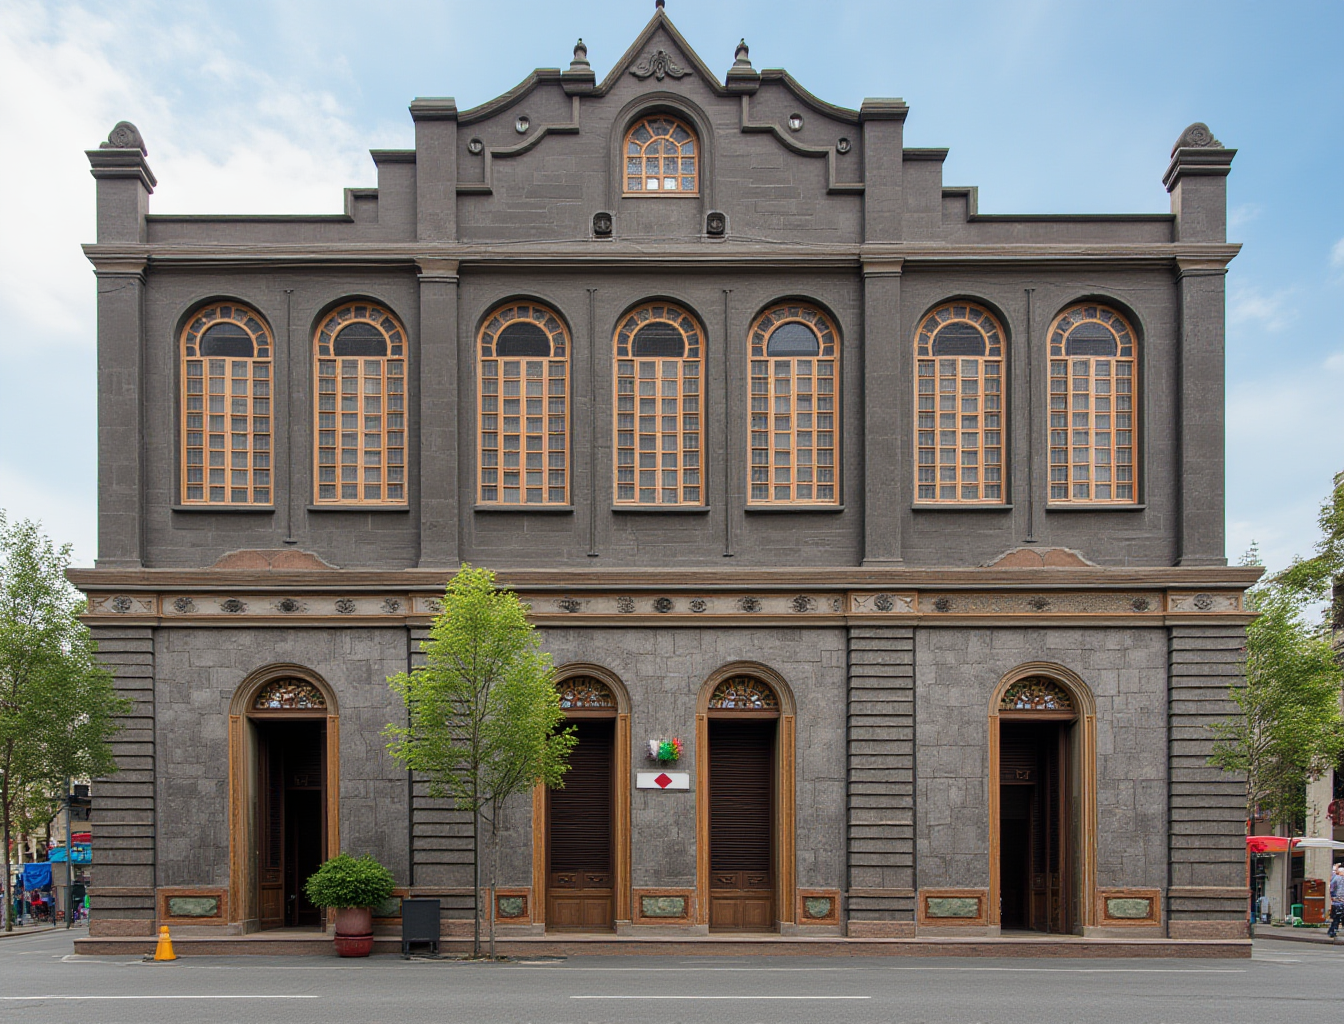

In [10]:
prompt = '[architectural_heritage] an architectural heritage'
#global_style_image = global_style_image
global_style_image = None
image_stage1 = generator.stage1(control_image, seed=111, prompt=prompt, global_style_image=global_style_image, controlnet_conditioning_scale=[0.4])
image_stage1

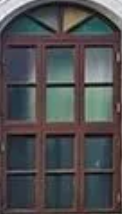

In [25]:
region_style_image = Image.open('temp/Snipaste_2023-02-21_13-33-51_window.png')
region_style_image

  0%|          | 0/20 [00:00<?, ?it/s]

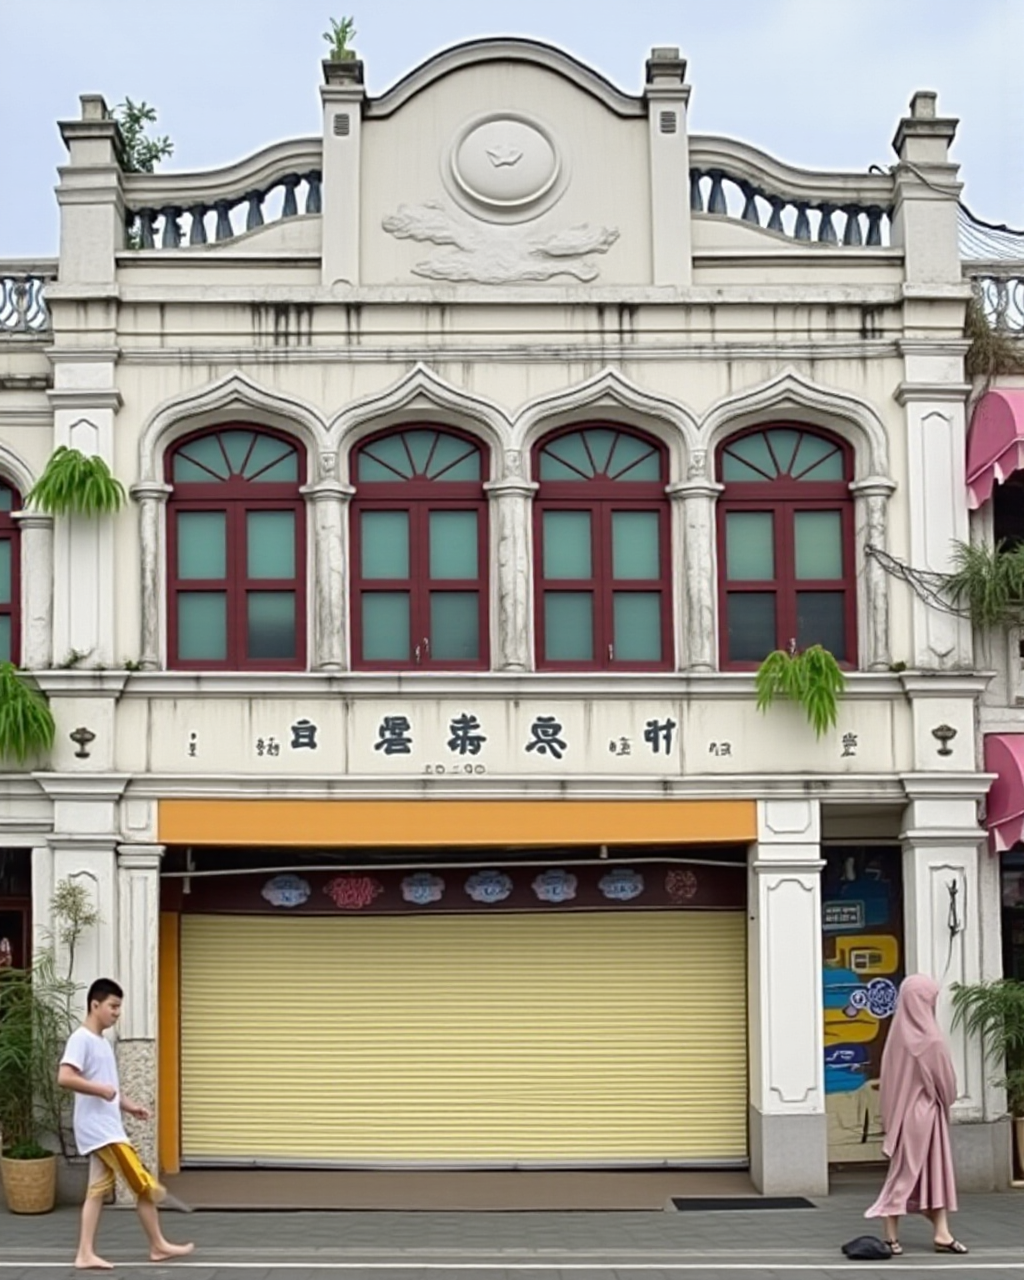

In [26]:
image_stage2 = generator.stage2(image_stage1, 'window', region_style_image, seed=42)
image_stage2